# OptiCrop Exploratory Data Analysis

Run each cell one by one to see dataset output, tables, and plots directly below the cell. Figures are also saved to `outputs/figures/`.

## 1. Import Libraries and Project Config

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

ROOT = Path.cwd()
if (ROOT / "config.py").exists():
    PROJECT_ROOT = ROOT
elif (ROOT.parent / "config.py").exists():
    PROJECT_ROOT = ROOT.parent
else:
    PROJECT_ROOT = Path(r"D:\\OptiCrop - Smart Agricultural Production Optimization Engine")

sys.path.insert(0, str(PROJECT_ROOT))
import config

sns.set_theme(style="whitegrid", palette="viridis")
FIG = config.FIGURE_DIR
FIG.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Dataset path:", config.DATA_FILE)
print("Figure output folder:", FIG)

Project root: d:\OptiCrop - Smart Agricultural Production Optimization Engine
Dataset path: D:\OptiCrop - Smart Agricultural Production Optimization Engine\data\Crop_recommendation.csv
Figure output folder: D:\OptiCrop - Smart Agricultural Production Optimization Engine\outputs\figures


## 2. Load Dataset

In [2]:
df = pd.read_csv(config.DATA_FILE)
print(f"Loaded dataset: {df.shape[0]} rows x {df.shape[1]} columns")
df.head()

Loaded dataset: 2200 rows x 8 columns


,N,P,K,temperature,humidity,ph,rainfall,label
0,103,25,55,27.43,86.12,6.47,19.78,muskmelon
1,81,26,43,26.26,49.36,6.16,51.89,watermelon
2,62,61,55,35.41,91.66,6.80,154.52,papaya
3,56,59,36,34.36,87.81,6.40,132.16,papaya
4,23,150,182,23.89,92.10,5.31,113.34,apple


## 3. Dataset Structure and Null Values

In [3]:
print("Data types:")
display(df.dtypes.to_frame("dtype"))

print("Null values:")
display(df.isnull().sum().to_frame("null_count"))

print("Dataset shape:", df.shape)

Data types:


,dtype
N,int64
P,int64
K,int64
temperature,float64
humidity,float64
ph,float64
rainfall,float64
label,object


Null values:


,null_count
N,0
P,0
K,0
temperature,0
humidity,0
ph,0
rainfall,0
label,0


Dataset shape: (2200, 8)


## 4. Crop Class Distribution

,count
label,
muskmelon,100
watermelon,100
papaya,100
apple,100
mango,100
mothbeans,100
mungbean,100
lentil,100
blackgram,100


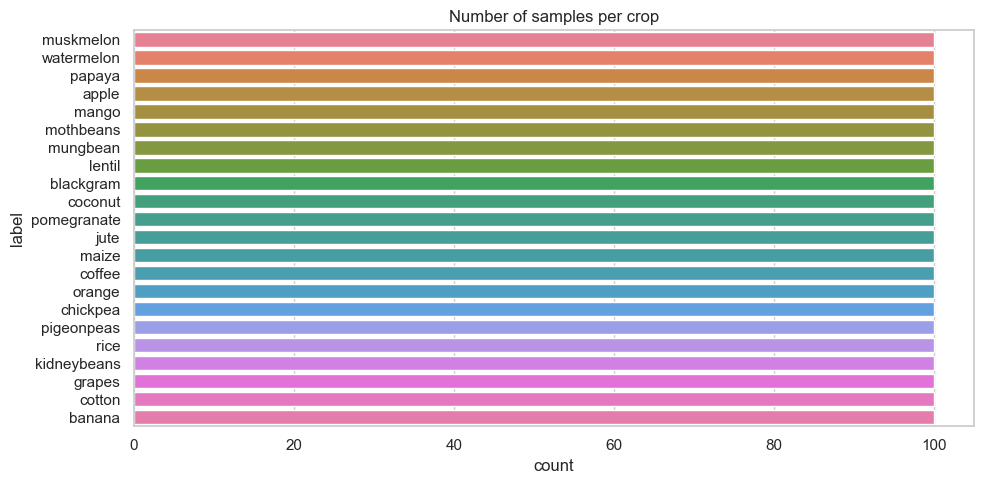

In [4]:
crop_counts = df[config.TARGET_COLUMN].value_counts()
display(crop_counts.to_frame("count"))

fig, ax = plt.subplots(figsize=(10, 5))
sns.countplot(
    y=config.TARGET_COLUMN,
    data=df,
    order=crop_counts.index,
    hue=config.TARGET_COLUMN,
    legend=False,
    ax=ax,
)
ax.set_title("Number of samples per crop")
fig.tight_layout()
fig.savefig(FIG / "univariate_crop_count.png", dpi=120)
plt.show()

## 5. Univariate Analysis

Run this cell to see the distribution and boxplot for every numeric feature.

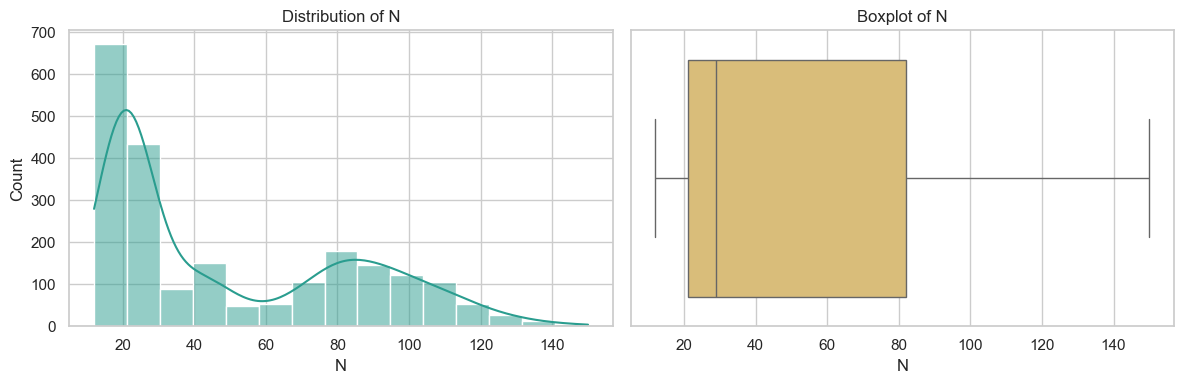

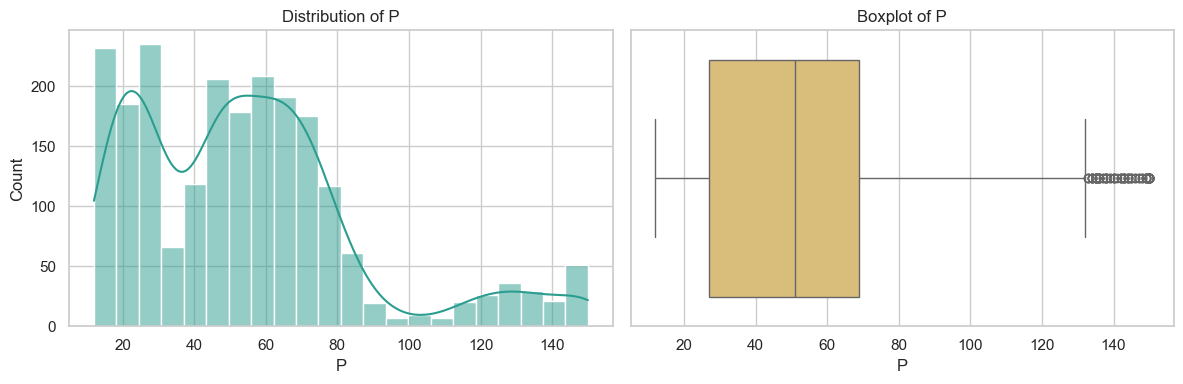

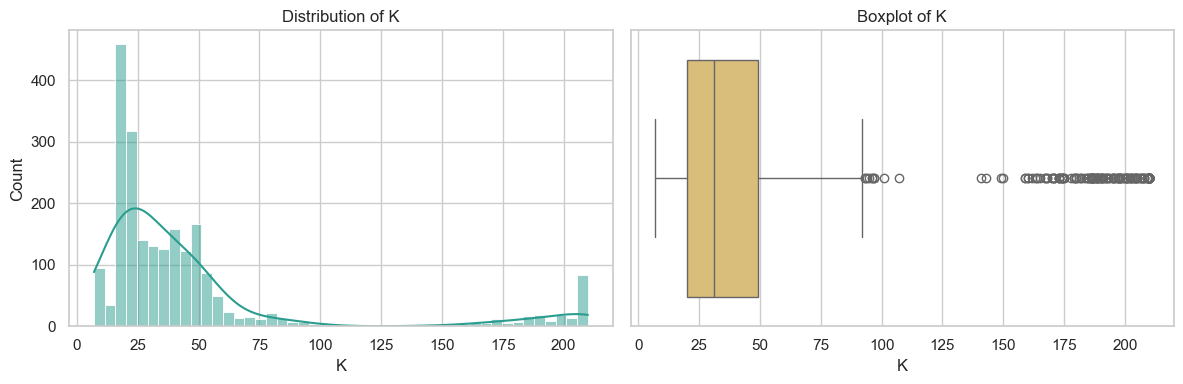

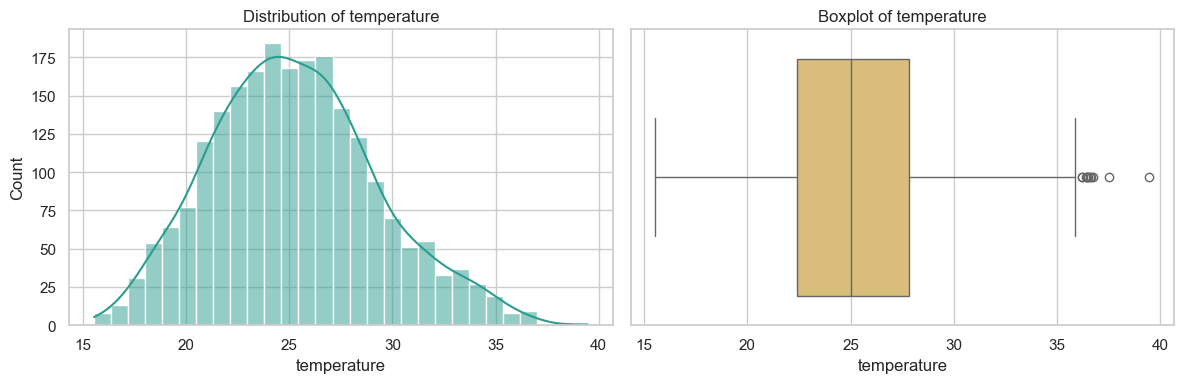

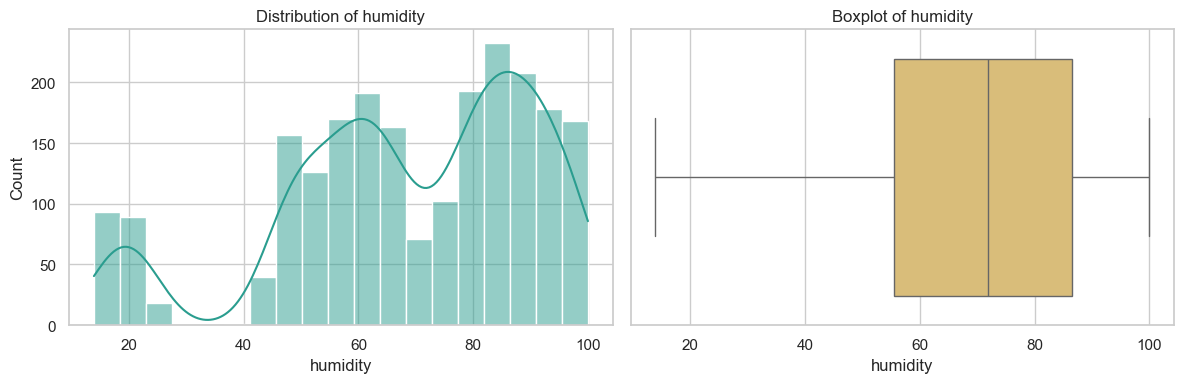

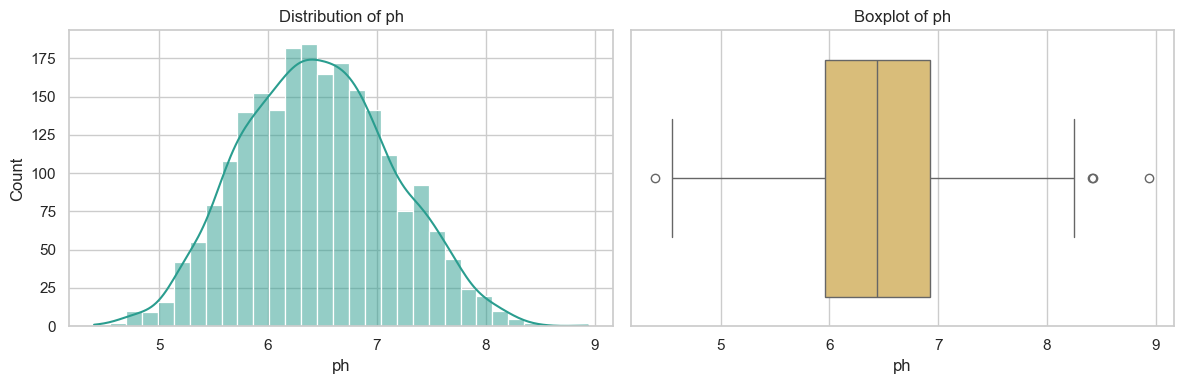

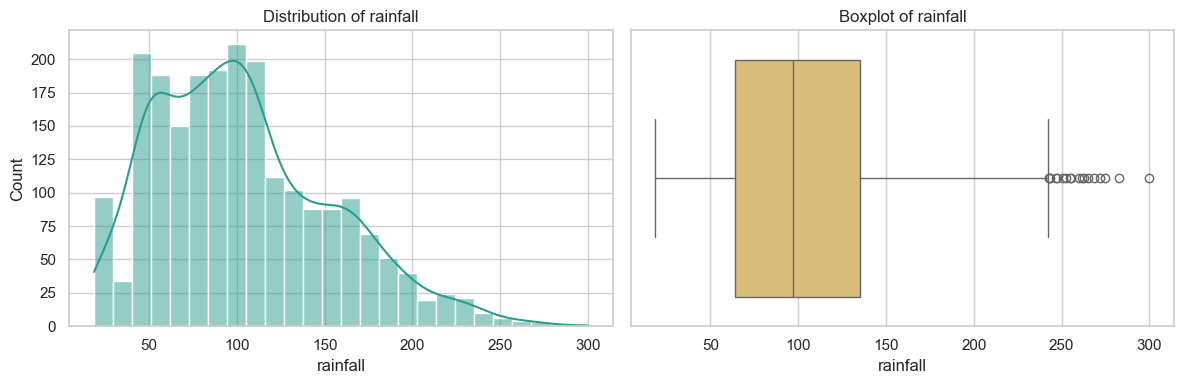

In [5]:
for col in config.FEATURE_COLUMNS:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    sns.histplot(df[col], kde=True, ax=axes[0], color="#2a9d8f")
    axes[0].set_title(f"Distribution of {col}")
    axes[0].set_xlabel(col)

    sns.boxplot(x=df[col], ax=axes[1], color="#e9c46a")
    axes[1].set_title(f"Boxplot of {col}")
    axes[1].set_xlabel(col)

    fig.tight_layout()
    fig.savefig(FIG / f"univariate_{col}.png", dpi=120)
    plt.show()

## 6. Bivariate Analysis: Humidity vs Crop

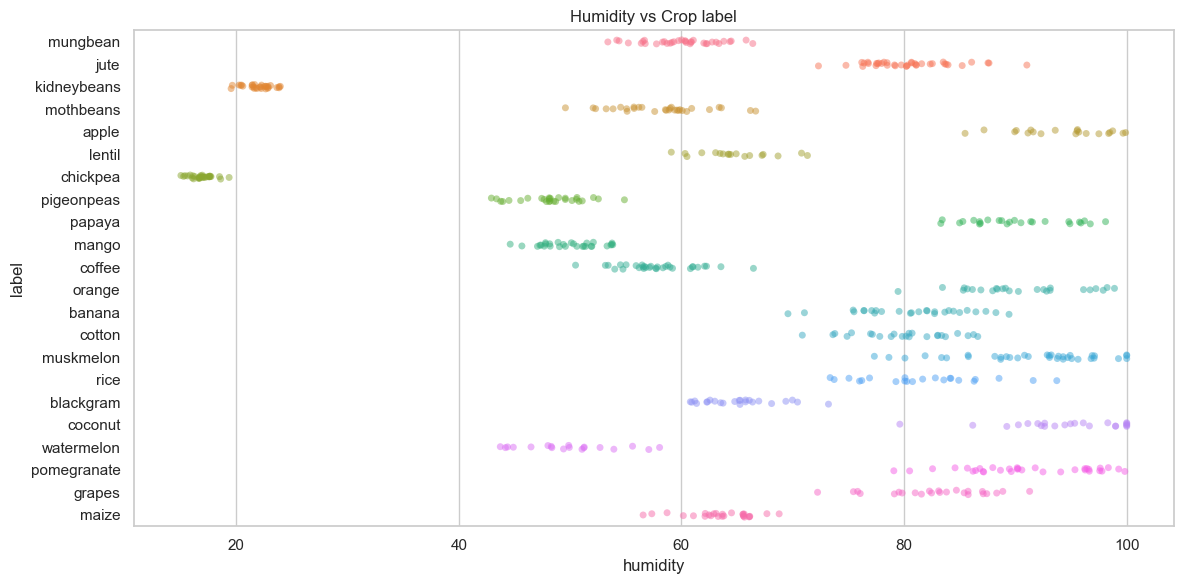

In [6]:
sample = df.sample(min(600, len(df)), random_state=config.RANDOM_STATE)

fig, ax = plt.subplots(figsize=(12, 6))
sns.stripplot(
    data=sample,
    x="humidity",
    y=config.TARGET_COLUMN,
    alpha=0.5,
    hue=config.TARGET_COLUMN,
    legend=False,
    ax=ax,
)
ax.set_title("Humidity vs Crop label")
fig.tight_layout()
fig.savefig(FIG / "bivariate_humidity_vs_crop.png", dpi=120)
plt.show()

## 7. Bivariate Analysis: Average N / P / K per Crop

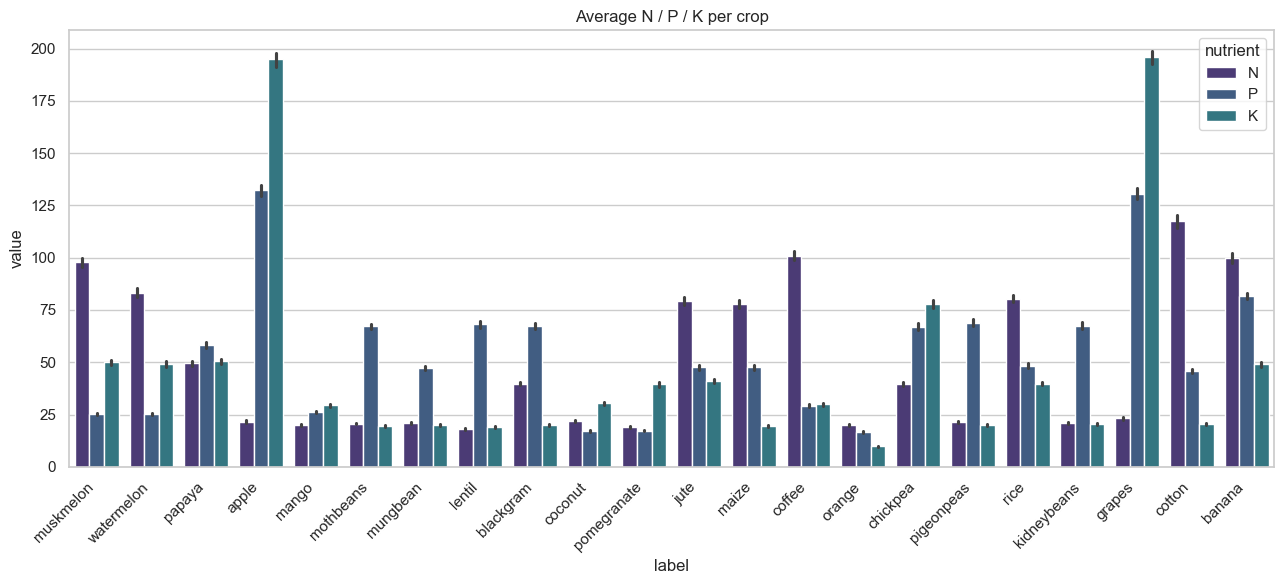

In [7]:
melted = df.melt(
    id_vars=config.TARGET_COLUMN,
    value_vars=["N", "P", "K"],
    var_name="nutrient",
    value_name="value",
)

fig, ax = plt.subplots(figsize=(13, 6))
sns.barplot(data=melted, x=config.TARGET_COLUMN, y="value", hue="nutrient", ax=ax)
ax.set_title("Average N / P / K per crop")
ax.tick_params(axis="x", rotation=45)
for label in ax.get_xticklabels():
    label.set_horizontalalignment("right")
fig.tight_layout()
fig.savefig(FIG / "bivariate_npk_per_crop.png", dpi=120)
plt.show()

## 8. Multivariate Analysis: Correlation Heatmap

,N,P,K,temperature,humidity,ph,rainfall
N,1.00,-0.21,-0.14,0.07,0.15,0.11,0.10
P,-0.21,1.00,0.72,-0.16,-0.04,-0.16,-0.12
K,-0.14,0.72,1.00,-0.22,0.22,-0.21,-0.05
temperature,0.07,-0.16,-0.22,1.00,0.23,-0.03,-0.05
humidity,0.15,-0.04,0.22,0.23,1.00,-0.06,0.22
ph,0.11,-0.16,-0.21,-0.03,-0.06,1.00,-0.18
rainfall,0.10,-0.12,-0.05,-0.05,0.22,-0.18,1.00


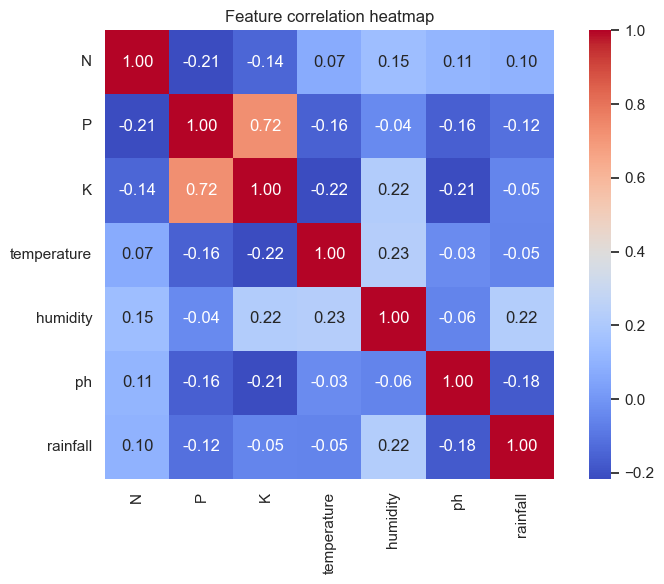

In [8]:
corr = df[config.FEATURE_COLUMNS].corr()
display(corr.round(2))

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", square=True, ax=ax)
ax.set_title("Feature correlation heatmap")
fig.tight_layout()
fig.savefig(FIG / "multivariate_correlation.png", dpi=120)
plt.show()

## 9. Multivariate Analysis: Pairplot

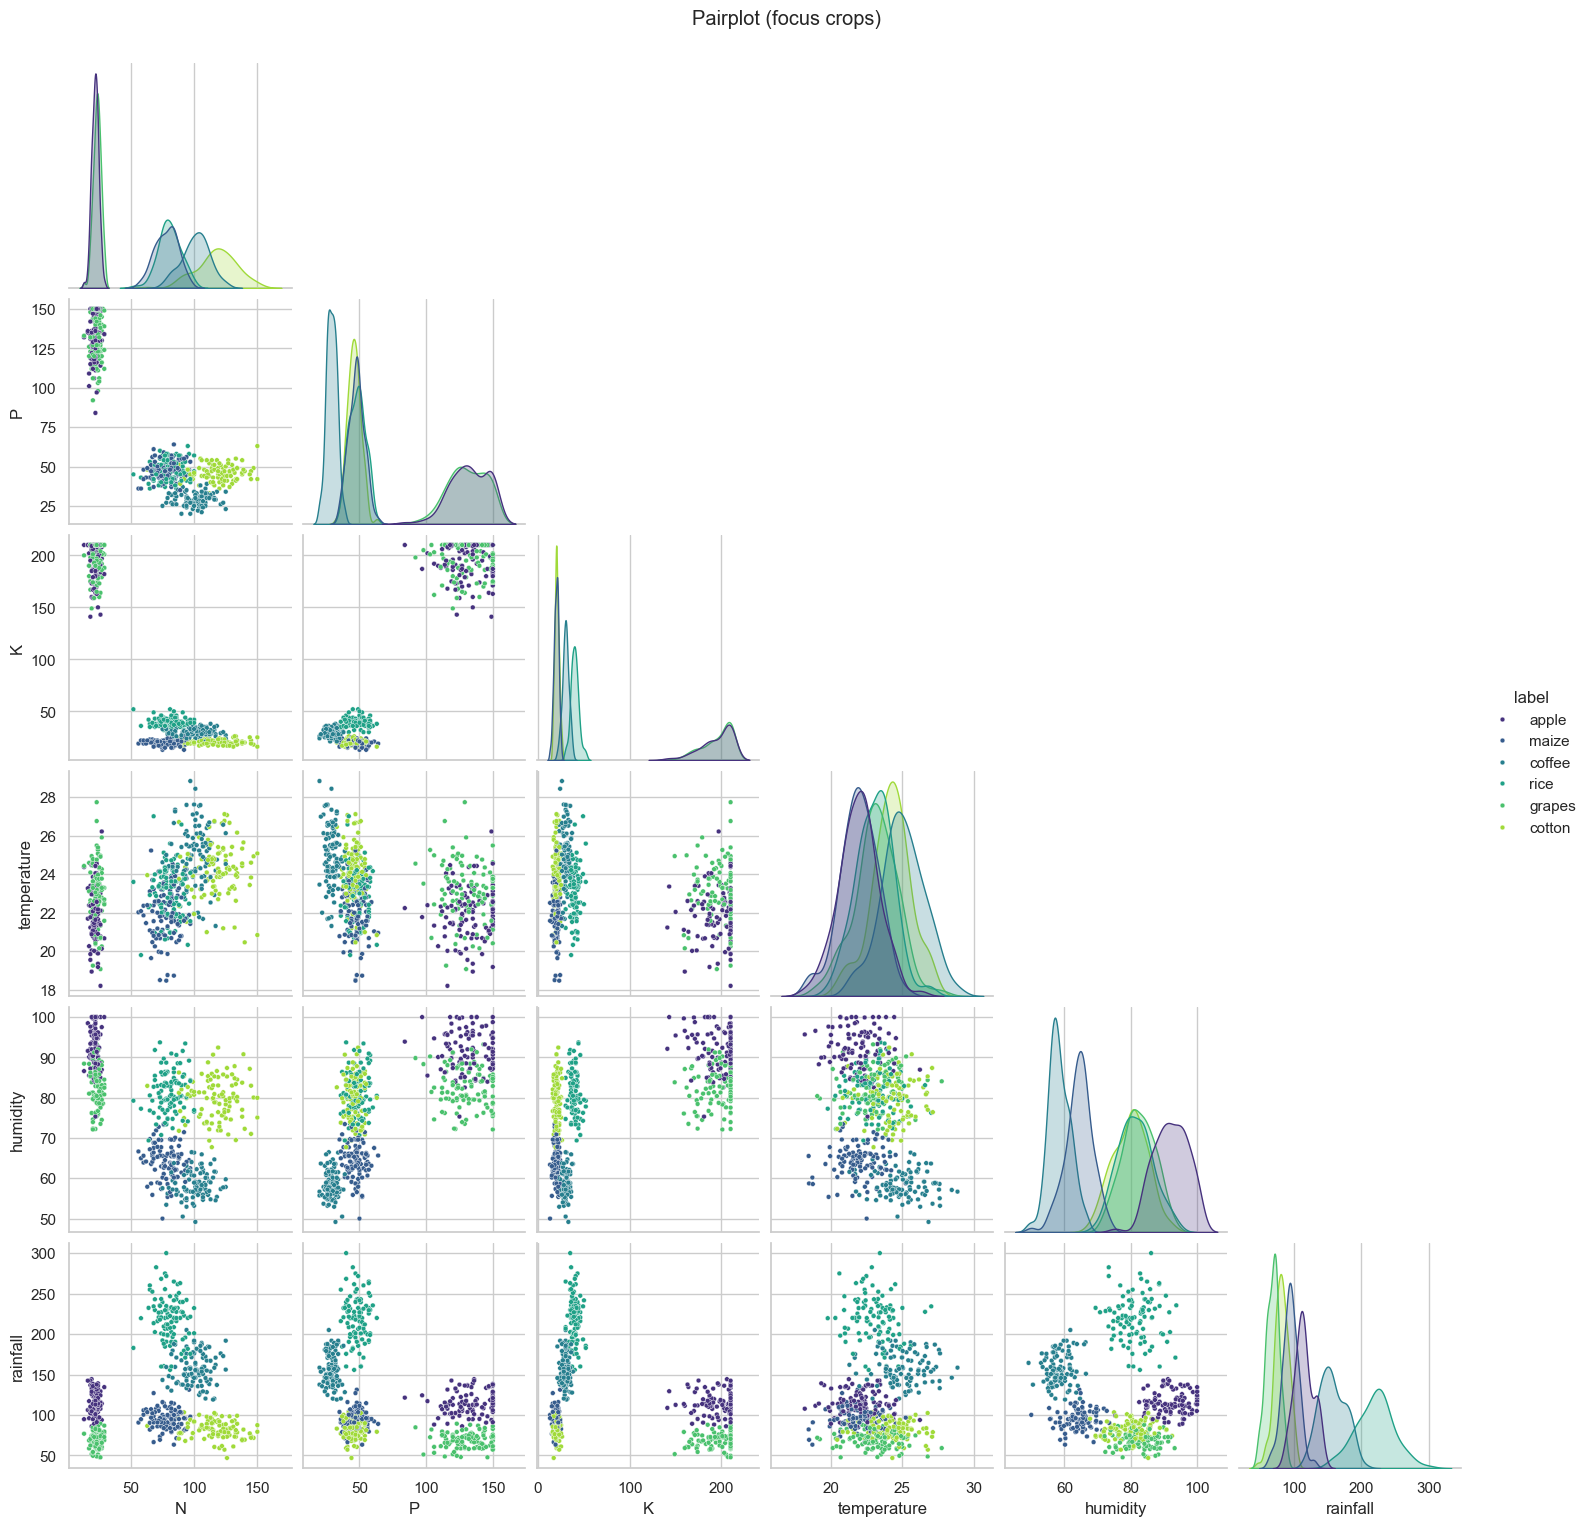

In [9]:
focus = ["rice", "maize", "apple", "grapes", "cotton", "coffee"]
sub = df[df[config.TARGET_COLUMN].isin(focus)]

pair = sns.pairplot(
    sub,
    vars=["N", "P", "K", "temperature", "humidity", "rainfall"],
    hue=config.TARGET_COLUMN,
    corner=True,
    plot_kws={"s": 12},
)
pair.fig.suptitle("Pairplot (focus crops)", y=1.02)
pair.fig.savefig(FIG / "multivariate_pairplot.png", dpi=110)
plt.show()

## 10. Descriptive Analysis

In [10]:
summary = df.describe().round(2)
summary.to_csv(config.OUTPUT_DIR / "descriptive_stats.csv")
display(summary)

per_crop = df.groupby(config.TARGET_COLUMN)[config.FEATURE_COLUMNS].mean().round(2)
per_crop.to_csv(config.OUTPUT_DIR / "mean_per_crop.csv")
display(per_crop)

print("Saved:", config.OUTPUT_DIR / "descriptive_stats.csv")
print("Saved:", config.OUTPUT_DIR / "mean_per_crop.csv")

,N,P,K,temperature,humidity,ph,rainfall
count,2200.00,2200.00,2200.00,2200.00,2200.00,2200.00,2200.00
mean,49.72,54.62,47.49,25.26,68.72,6.46,103.48
std,34.68,31.89,49.68,4.03,22.03,0.69,50.41
min,12.00,12.00,7.00,15.54,13.89,4.40,18.60
25%,21.00,27.00,20.00,22.41,55.58,5.96,63.85
50%,29.00,51.00,31.00,25.01,71.82,6.44,96.98
75%,82.00,69.00,49.00,27.83,86.46,6.92,135.22
max,150.00,150.00,210.00,39.48,100.00,8.94,300.00


,N,P,K,temperature,humidity,ph,rainfall
label,,,,,,,
apple,21.62,132.21,194.80,21.95,92.01,5.87,115.03
banana,99.78,81.50,48.95,27.17,80.63,5.94,104.42
blackgram,39.81,67.35,19.83,30.11,65.17,7.10,70.36
chickpea,39.54,67.01,77.90,17.99,16.82,7.27,78.92
coconut,21.91,17.04,30.31,27.07,94.25,5.90,174.80
coffee,101.05,29.06,29.80,25.02,58.41,6.76,157.12
cotton,117.62,45.86,20.29,24.19,79.77,6.90,81.71
grapes,23.20,130.60,195.76,23.13,82.31,5.98,68.77
jute,79.27,47.62,41.00,24.99,80.80,6.68,172.11


Saved: D:\OptiCrop - Smart Agricultural Production Optimization Engine\outputs\descriptive_stats.csv
Saved: D:\OptiCrop - Smart Agricultural Production Optimization Engine\outputs\mean_per_crop.csv


## Done

All plots are displayed below their cells and saved in `outputs/figures/`.